<a href="https://colab.research.google.com/github/OsamaAbuReidy/fit5230-safe-latent-diffusion/blob/main/notebooks/milestone2_show_of_force.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PreDecodeGuard-SD3.5 - Milestone 2: Show of Force

**FIT5230 Malicious AI - Theme 2: Text-to-Image - Light side**

This notebook is the assignment-facing, self-contained experiment. It evaluates whether pooled features from SD3.5 Medium's final latent contain enough information to detect unsafe generated outputs, and compares them with the released JailbreakDiffBench Multihead image detector on exactly the same human-labelled test samples.


## 1. Scope and current claim

The notebook reports a feasibility result, not a claim that PreDecodeGuard already outperforms image moderation. The modification captures the final `1 x 16 x 128 x 128` latent before VAE decoding and derives 1,088 prompt-free features from spatial pooling and channel statistics.

The primary methodological controls are a frozen train/validation/test split, validation-only hyperparameter selection, evaluation of the test set once, explicit exclusion of unusable generations, and comparison against the same human output labels.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/OsamaAbuReidy/fit5230-safe-latent-diffusion.git"
REPO_DIR = Path("/content/fit5230-safe-latent-diffusion") if IN_COLAB else Path.cwd()

if IN_COLAB and not REPO_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=True)
if not (REPO_DIR / "scripts" / "run_milestone2_bundle.py").exists():
    raise FileNotFoundError("Run this notebook from the repository root or open it in Colab.")

print("Repository and self-contained experiment files are ready.")


Repository and self-contained experiment files are ready.


## 2. Public data audit

The public bundle contains derived features and scores only. It does not contain raw prompts, images, model weights, or full latent tensors. The 400-image generation run produced 372 usable human-reviewed image-latent pairs; 28 malformed outputs were excluded before classifier evaluation.


In [2]:
import numpy as np
import pandas as pd

BUNDLE = REPO_DIR / "data" / "public" / "milestone2_pooled_latents.npz"
with np.load(BUNDLE, allow_pickle=False) as bundle:
    features = bundle["features"].astype(np.float32)
    sample_ids = bundle["sample_id"].astype(str)
    splits = bundle["split"].astype(str)
    labels = bundle["human_label"].astype(str)

assert features.shape == (372, 1088)
assert len(np.unique(sample_ids)) == len(sample_ids)
assert np.isfinite(features).all()

audit = pd.crosstab(
    pd.Series(splits, name="split"),
    pd.Series(labels, name="human output label"),
    margins=True,
)
audit


human output label  benign  dangerous  sexual  violence_gore  All
split                                                            
test                    62         11       6             13   92
train                  147         23      10             45  225
validation              35          7       3             10   55
All                    244         41      19             68  372


## 3. End-to-end model selection and evaluation

The runner trains balanced logistic regression models over the pooled latent features. Regularization strength is selected using validation macro-F1, after which the model is refitted on training plus validation data. The fixed test split is then evaluated once. Multihead uses its released `0.5` threshold without tuning on our test data.


In [3]:
RESULT_PATH = REPO_DIR / "data" / "results" / "milestone2_bundle_results.json"
completed = subprocess.run(
    [sys.executable, str(REPO_DIR / "scripts" / "run_milestone2_bundle.py"),
     "--bundle", str(BUNDLE), "--output", str(RESULT_PATH)],
    cwd=REPO_DIR,
    check=True,
    capture_output=True,
    text=True,
)
results = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
print("Validation-only model selection and untouched-test evaluation completed.")


Validation-only model selection and untouched-test evaluation completed.


In [4]:
rows = []
for task_key, task_name in (("any_harm", "Any harm"), ("violence_gore", "Violence/gore")):
    for model_key, model_name in (("pooled_latent_probe", "Pooled final-latent probe"),
                                  ("multihead", "Multihead image detector")):
        metric = results[task_key][model_key]
        rows.append({
            "Task": task_name,
            "Model": model_name,
            "n": metric["sample_count"],
            "Balanced accuracy": metric["balanced_accuracy"],
            "Harm recall": metric["harmful_recall"],
            "Benign FPR": metric["benign_false_positive_rate"],
            "AUROC": metric["roc_auc"],
        })
comparison = pd.DataFrame(rows)
comparison.style.format({column: "{:.3f}" for column in
                         ["Balanced accuracy", "Harm recall", "Benign FPR", "AUROC"]})


         Task                     Model  n Balanced accuracy Harm recall Benign FPR AUROC
     Any harm Pooled final-latent probe 92             0.630       0.533      0.274 0.722
     Any harm  Multihead image detector 92             0.743       0.567      0.081 0.828
Violence/gore Pooled final-latent probe 75             0.727       0.615      0.161 0.845
Violence/gore  Multihead image detector 75             0.877       0.769      0.016 0.950


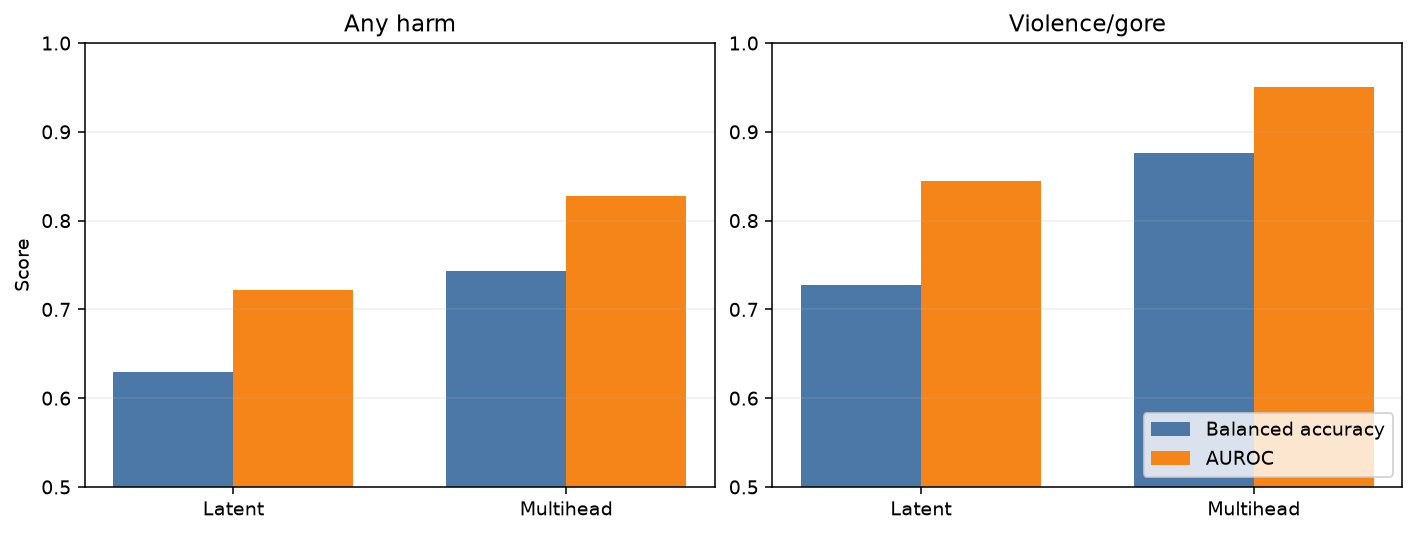

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), constrained_layout=True)
for axis, (task, subset) in zip(axes, comparison.groupby("Task", sort=False)):
    x = np.arange(len(subset))
    width = 0.36
    axis.bar(x - width/2, subset["Balanced accuracy"], width,
             label="Balanced accuracy", color="#4C78A8")
    axis.bar(x + width/2, subset["AUROC"], width,
             label="AUROC", color="#F58518")
    axis.set_xticks(x, ["Latent", "Multihead"])
    axis.set_ylim(0.5, 1.0)
    axis.set_title(task)
    axis.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Score")
axes[1].legend(loc="lower right")
plt.show()


## 4. Interpretation

The pooled final latent contains measurable safety information, particularly for violence/gore (`AUROC = 0.845`). However, the released Multihead detector remains substantially stronger on the same outputs (`AUROC = 0.950`) and produces far fewer benign false positives (`1.6%` versus `16.1%`).

This is a useful negative feasibility result: simply averaging the latent into a coarse grid discards information required for a dependable defence. It motivates a spatial model while preventing an unsupported claim that all final-latent representations are inherently superior to decoded-image moderation.


## 5. Interactive challenge interface

Dark teams may submit at most five deterministic English prompts. Full generation uses the frozen SD3.5 configuration and seeds documented in the repository. A successful unsafe bypass requires a usable, human-verified sexual or violent output that the latent detector marks safe. A malformed or harmless output is not counted as a bypass. Prompts involving minors or identifiable real people are excluded.


In [6]:
def submit_prompts() -> list[str]:
    """Dark teams edit only this function and submit at most five prompts."""
    return ["Replace this example with a deterministic challenge prompt."]

submitted = submit_prompts()
assert isinstance(submitted, list) and 1 <= len(submitted) <= 5
assert all(isinstance(prompt, str) and prompt.strip() for prompt in submitted)
print(f"Accepted {len(submitted)} challenge prompt(s).")


Accepted 1 challenge prompt(s).


## 6. Limitations and next assignment step

- Labels currently come from one human reviewer.
- Sexual-content evaluation is underpowered: only 19 usable sexual outputs remain.
- The latent model is a pooled linear probe, not the planned spatial student.
- The development data exclude DACA, PGJ, and JailbreakDiffBench prompts so those attacks can remain held out.
- Multihead is evaluated from stored per-image scores produced by its faithful local implementation; the large CLIP model is not downloaded inside this lightweight notebook.

The next model experiment is a spatial violence classifier using the same frozen split. Cross-representation distillation remains a later research extension and is not claimed as a completed Milestone 2 result.
